# The aim of this file is to understand the raw data we collected.

The scaper was unable to collect the floor vs total floors correctly so we had to impute 1221 floors_total values by assuming the apartment had double the amount of floors.

One other way to try would be impute by the average ratio of floor number to total floors.

## First we install necessary imports


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import os

## load data


In [3]:
listing_data = pd.read_csv('raw_data/listings.csv')
images_data = pd.read_csv('raw_data/images.csv')

# EDA
- remove the lisitings with less than 5 images and remove images from images.csv


In [4]:
listing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5088 entries, 0 to 5087
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_id        5088 non-null   int64  
 1   url              5088 non-null   str    
 2   price_man_yen    5045 non-null   float64
 3   layout           5019 non-null   str    
 4   area_sqm         5072 non-null   float64
 5   year_built       5088 non-null   int64  
 6   floor_number     5072 non-null   float64
 7   floors_total     5072 non-null   float64
 8   address          5088 non-null   str    
 9   nearest_station  5073 non-null   str    
 10  walk_minutes     5073 non-null   float64
 11  image_count      5088 non-null   int64  
dtypes: float64(5), int64(3), str(4)
memory usage: 477.1 KB


In [5]:
images_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 96864 entries, 0 to 96863
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   source_id    96864 non-null  int64
 1   listing_url  96864 non-null  str  
 2   image_url    96864 non-null  str  
 3   image_name   96864 non-null  str  
dtypes: int64(1), str(3)
memory usage: 3.0 MB


In [6]:
listing_data.describe()

,source_id,price_man_yen,area_sqm,year_built,floor_number,floors_total,walk_minutes,image_count
count,5.088000e+03,5045.000000,5072.000000,5088.000000,5072.000000,5072.000000,5073.000000,5088.000000
mean,4.763850e+07,11803.492369,66.179310,1998.210888,7.941049,7.402405,7.579144,19.037736
std,2.922755e+07,12564.494834,21.982676,15.648618,8.545785,6.820337,4.665559,16.326160
min,2.000007e+07,420.000000,16.510000,1964.000000,1.000000,1.000000,1.000000,1.000000
25%,2.021222e+07,4999.000000,53.760000,1983.000000,3.000000,2.000000,4.000000,11.000000
50%,2.035383e+07,7998.000000,64.180000,2000.000000,5.000000,7.000000,7.000000,22.000000
75%,7.890019e+07,13999.000000,75.410000,2010.000000,9.000000,11.000000,10.000000,27.000000
max,7.923565e+07,216800.000000,383.640000,2026.000000,59.000000,58.000000,46.000000,805.000000


In [7]:
listing_data.shape

(5088, 12)

In [8]:
images_data.shape

(96864, 4)

In [9]:
listing_data.columns

Index(['source_id', 'url', 'price_man_yen', 'layout', 'area_sqm', 'year_built',
       'floor_number', 'floors_total', 'address', 'nearest_station',
       'walk_minutes', 'image_count'],
      dtype='str')

In [10]:
images_data.columns

Index(['source_id', 'listing_url', 'image_url', 'image_name'], dtype='str')

In [11]:
listing_data.source_id.nunique()

5088

In [12]:
images_data.source_id.nunique()

5088

In [13]:
listing_data.isna().any()

source_id          False
url                False
price_man_yen       True
layout              True
area_sqm            True
year_built         False
floor_number        True
floors_total        True
address            False
nearest_station     True
walk_minutes        True
image_count        False
dtype: bool

In [14]:
listing_data = listing_data.dropna()

In [15]:
listing_data

,source_id,url,price_man_yen,layout,area_sqm,year_built,floor_number,floors_total,address,nearest_station,walk_minutes,image_count
0,20143760,https://suumo.jp/ms/chuko/chiba/sc_ichikawa/nc...,5280.0,4LDK,77.31,2000,3.0,5.0,千葉県市川市新井３ [ ■ 周辺環境 ],南行徳駅,7.0,1
1,20143796,https://suumo.jp/ms/chuko/chiba/sc_ichikawa/nc...,3799.0,3LDK,66.00,2000,3.0,6.0,千葉県市川市広尾１ [ ■ 周辺環境 ],南行徳駅,17.0,1
3,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1480.0,1K,32.72,1988,4.0,4.0,東京都足立区栗原２ [ ■ 周辺環境 ],西新井駅,10.0,10
4,20277732,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2390.0,2LDK,52.89,1989,4.0,4.0,東京都足立区六月１ [ ■ 周辺環境 ],竹ノ塚駅,16.0,24
5,20332918,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1580.0,1DK,29.16,1976,6.0,9.0,東京都足立区東和５ [ ■ 周辺環境 ],北綾瀬駅,12.0,31
...,...,...,...,...,...,...,...,...,...,...,...,...
5074,78586303,https://suumo.jp/ms/chuko/tokyo/sc_shinjuku/nc...,19990.0,2LDK,79.02,2007,20.0,1.0,東京都新宿区四谷４ [ ■ 周辺環境 ],四谷三丁目駅,5.0,28
5075,78530920,https://suumo.jp/ms/chuko/tokyo/sc_sumida/nc_7...,21800.0,2LDK,80.38,2006,38.0,2.0,東京都墨田区太平４-１－１ [ ■ 周辺環境 ],錦糸町駅,4.0,29
5076,20331756,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,29800.0,2LDK,96.40,2005,1.0,1.0,東京都渋谷区広尾３ [ ■ 周辺環境 ],恵比寿駅,16.0,13
5077,20352336,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,45800.0,2LDK,91.39,2026,1.0,1.0,東京都渋谷区大山町 [ ■ 周辺環境 ],代々木上原駅,8.0,21


In [16]:
images_data.isna().any()

source_id      False
listing_url    False
image_url      False
image_name     False
dtype: bool

In [17]:
#keep only the listings that have 5 or more images
listing_data = listing_data[listing_data['image_count'] >= 5]
listing_data

,source_id,url,price_man_yen,layout,area_sqm,year_built,floor_number,floors_total,address,nearest_station,walk_minutes,image_count
3,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1480.0,1K,32.72,1988,4.0,4.0,東京都足立区栗原２ [ ■ 周辺環境 ],西新井駅,10.0,10
4,20277732,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2390.0,2LDK,52.89,1989,4.0,4.0,東京都足立区六月１ [ ■ 周辺環境 ],竹ノ塚駅,16.0,24
5,20332918,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1580.0,1DK,29.16,1976,6.0,9.0,東京都足立区東和５ [ ■ 周辺環境 ],北綾瀬駅,12.0,31
6,20344616,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2380.0,2LDK,53.04,1974,3.0,8.0,東京都足立区梅田７-22-9 [ ■ 周辺環境 ],梅島駅,7.0,27
7,78385243,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_7...,1700.0,2DK,40.10,1985,1.0,5.0,東京都足立区青井１-16-9 [ ■ 周辺環境 ],青井駅,10.0,11
...,...,...,...,...,...,...,...,...,...,...,...,...
5074,78586303,https://suumo.jp/ms/chuko/tokyo/sc_shinjuku/nc...,19990.0,2LDK,79.02,2007,20.0,1.0,東京都新宿区四谷４ [ ■ 周辺環境 ],四谷三丁目駅,5.0,28
5075,78530920,https://suumo.jp/ms/chuko/tokyo/sc_sumida/nc_7...,21800.0,2LDK,80.38,2006,38.0,2.0,東京都墨田区太平４-１－１ [ ■ 周辺環境 ],錦糸町駅,4.0,29
5076,20331756,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,29800.0,2LDK,96.40,2005,1.0,1.0,東京都渋谷区広尾３ [ ■ 周辺環境 ],恵比寿駅,16.0,13
5077,20352336,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,45800.0,2LDK,91.39,2026,1.0,1.0,東京都渋谷区大山町 [ ■ 周辺環境 ],代々木上原駅,8.0,21


In [18]:
#remove the images of listings not being used
images_data = images_data[images_data['source_id'].isin(listing_data['source_id'])]
images_data


,source_id,listing_url,image_url,image_name
26,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20101205_c236d31dd0.jpg
27,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20101205_99ba43ab8d.jpg
28,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20101205_10972b9e12.jpg
29,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20101205_ec94786bdf.jpg
30,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,https://suumo.jp/front/gazo/bukken/030/N010000...,20101205_67727e9e7f.jpg
...,...,...,...,...
96584,20341079,https://suumo.jp/ms/chuko/tokyo/sc_chiyoda/nc_...,https://suumo.jp/front/gazo/bukken/030/N010000...,20341079_8b0f9a9803.jpg
96585,20341079,https://suumo.jp/ms/chuko/tokyo/sc_chiyoda/nc_...,https://suumo.jp/front/gazo/bukken/030/N010000...,20341079_5b9c7b6289.jpg
96586,20341079,https://suumo.jp/ms/chuko/tokyo/sc_chiyoda/nc_...,https://suumo.jp/front/gazo/bukken/030/N010000...,20341079_d336954892.jpg
96587,20341079,https://suumo.jp/ms/chuko/tokyo/sc_chiyoda/nc_...,https://suumo.jp/front/gazo/bukken/030/N010000...,20341079_87a81befdd.jpg


## Inspecting the distributions of columns in listings data.

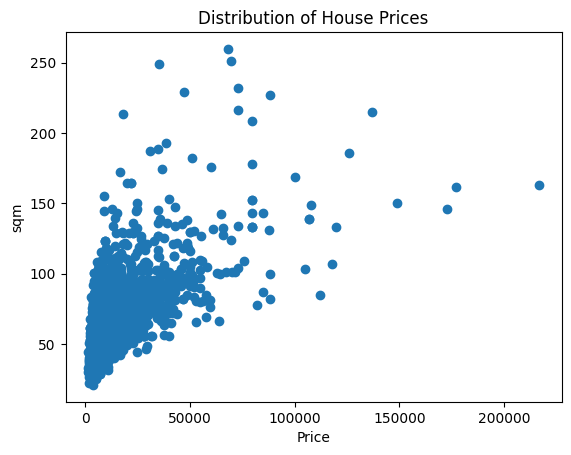

In [19]:
price = listing_data['price_man_yen']
sqm = listing_data['area_sqm']
plt.scatter(price,sqm)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("sqm")
plt.show()

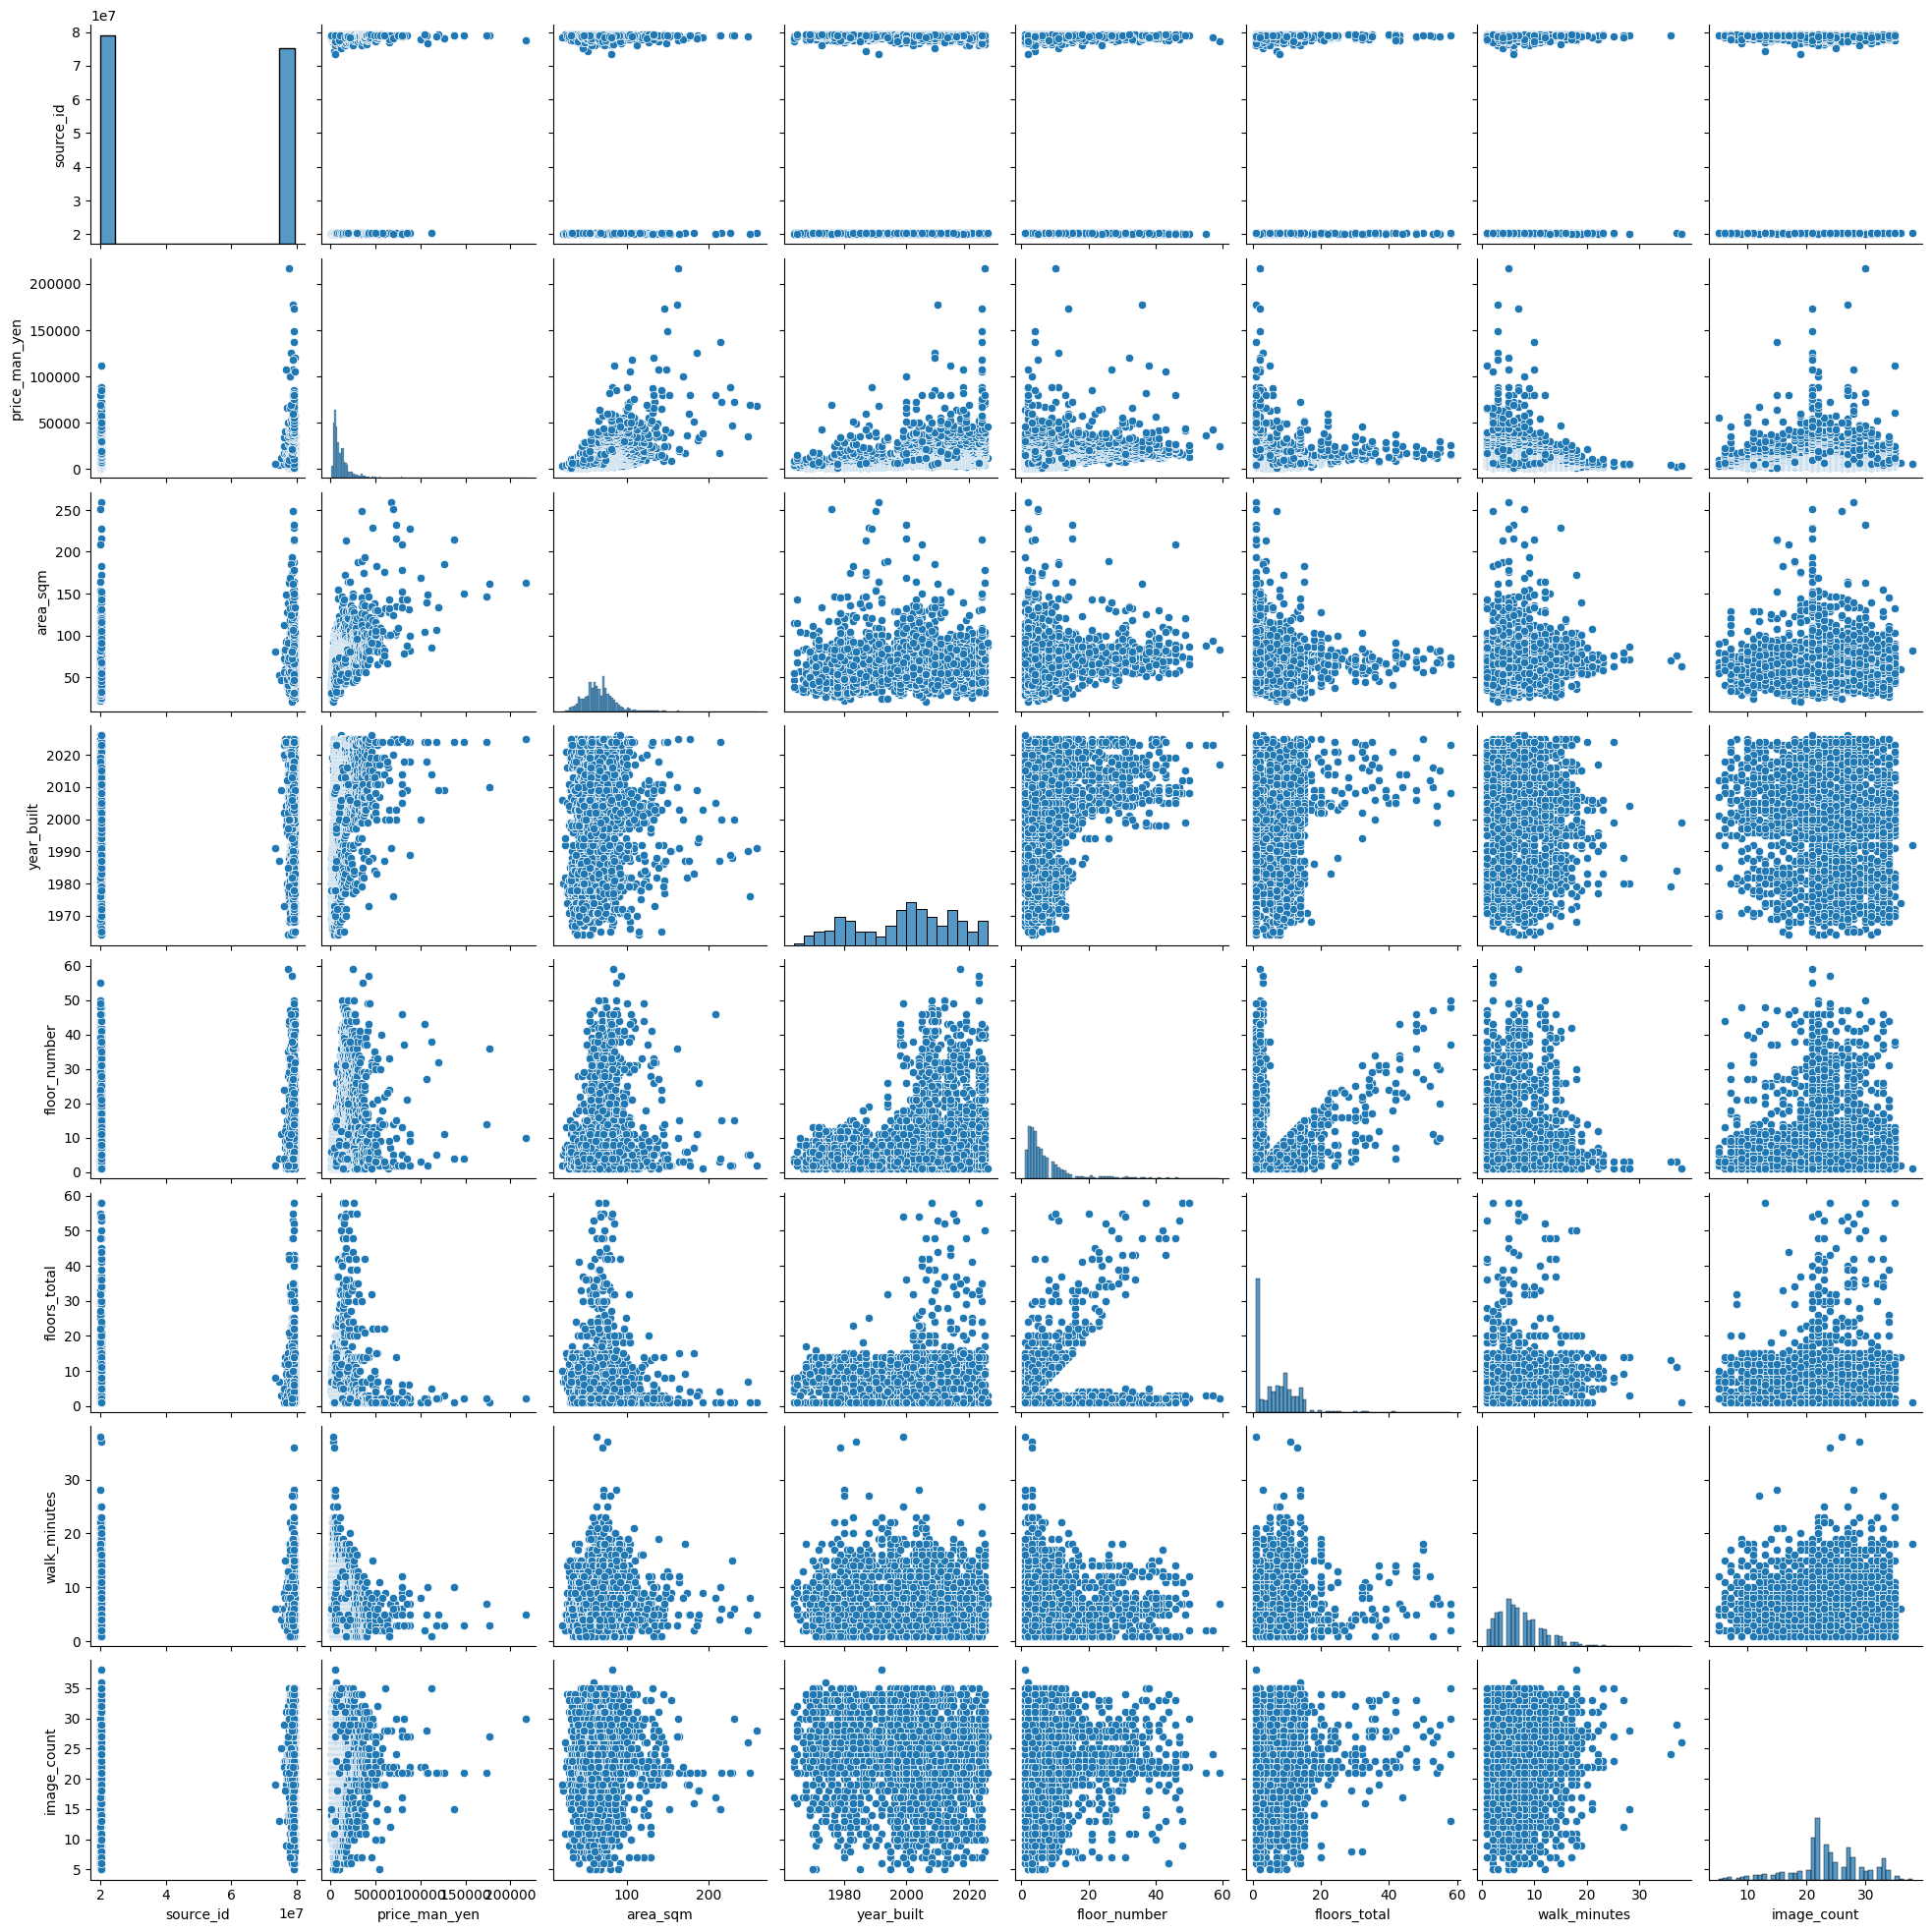

In [20]:
plot = sns.pairplot(listing_data)

### Why are some apartments on higher floor than total floors on building?

In [21]:
# find the number of listings that have floor number higher than floors_total
floating_apartments = listing_data[['source_id','floor_number', 'floors_total']]
floating_apartments = floating_apartments[floating_apartments['floor_number'] > floating_apartments['floors_total']]
new_total_floors = floating_apartments['floor_number'] * 2
floating_apartments['floors_total'] = new_total_floors
new_total_floors

189      8.0
194      8.0
207      8.0
254     10.0
255     14.0
        ... 
5067    10.0
5070     8.0
5074    40.0
5075    76.0
5078    16.0
Name: floor_number, Length: 1221, dtype: float64

In [22]:
#Function to replace floating apartments floors_total with double the floor_number value
def fix_floating(row):
    if row['floor_number'] > row['floors_total']:
        row['floors_total'] = row['floor_number'] * 2

    return row

In [23]:
listing_data.apply(fix_floating, axis=1)

,source_id,url,price_man_yen,layout,area_sqm,year_built,floor_number,floors_total,address,nearest_station,walk_minutes,image_count
3,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1480.0,1K,32.72,1988,4.0,4.0,東京都足立区栗原２ [ ■ 周辺環境 ],西新井駅,10.0,10
4,20277732,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2390.0,2LDK,52.89,1989,4.0,4.0,東京都足立区六月１ [ ■ 周辺環境 ],竹ノ塚駅,16.0,24
5,20332918,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1580.0,1DK,29.16,1976,6.0,9.0,東京都足立区東和５ [ ■ 周辺環境 ],北綾瀬駅,12.0,31
6,20344616,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2380.0,2LDK,53.04,1974,3.0,8.0,東京都足立区梅田７-22-9 [ ■ 周辺環境 ],梅島駅,7.0,27
7,78385243,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_7...,1700.0,2DK,40.10,1985,1.0,5.0,東京都足立区青井１-16-9 [ ■ 周辺環境 ],青井駅,10.0,11
...,...,...,...,...,...,...,...,...,...,...,...,...
5074,78586303,https://suumo.jp/ms/chuko/tokyo/sc_shinjuku/nc...,19990.0,2LDK,79.02,2007,20.0,40.0,東京都新宿区四谷４ [ ■ 周辺環境 ],四谷三丁目駅,5.0,28
5075,78530920,https://suumo.jp/ms/chuko/tokyo/sc_sumida/nc_7...,21800.0,2LDK,80.38,2006,38.0,76.0,東京都墨田区太平４-１－１ [ ■ 周辺環境 ],錦糸町駅,4.0,29
5076,20331756,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,29800.0,2LDK,96.40,2005,1.0,1.0,東京都渋谷区広尾３ [ ■ 周辺環境 ],恵比寿駅,16.0,13
5077,20352336,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,45800.0,2LDK,91.39,2026,1.0,1.0,東京都渋谷区大山町 [ ■ 周辺環境 ],代々木上原駅,8.0,21


# Inspect Categorical Features

In [56]:
listing_data['layout'].value_counts()

layout
2LDK     1497
3LDK     1377
1LDK      711
4LDK      115
2DK        70
1DK        63
1K         25
3DK        24
2K          4
5LDK        4
2SLDK       3
３LDK        3
1SLDK       3
4DK         2
２LDK        2
２DK         1
１R          1
3K          1
1R          1
6LDK        1
Name: count, dtype: int64

<Axes: xlabel='layout', ylabel='area_sqm'>

/Users/lance/.pyenv/versions/3.12.9/envs/clip-project/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 65298 (\N{FULLWIDTH DIGIT TWO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/lance/.pyenv/versions/3.12.9/envs/clip-project/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 65297 (\N{FULLWIDTH DIGIT ONE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/lance/.pyenv/versions/3.12.9/envs/clip-project/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 65299 (\N{FULLWIDTH DIGIT THREE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/lance/.pyenv/versions/3.12.9/envs/clip-project/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65298 (\N{FULLWIDTH DIGIT TWO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/lance/.pyenv/versions/3.12.9/envs/clip-project/lib/python3.12/site-packages/IPython/core/pyl

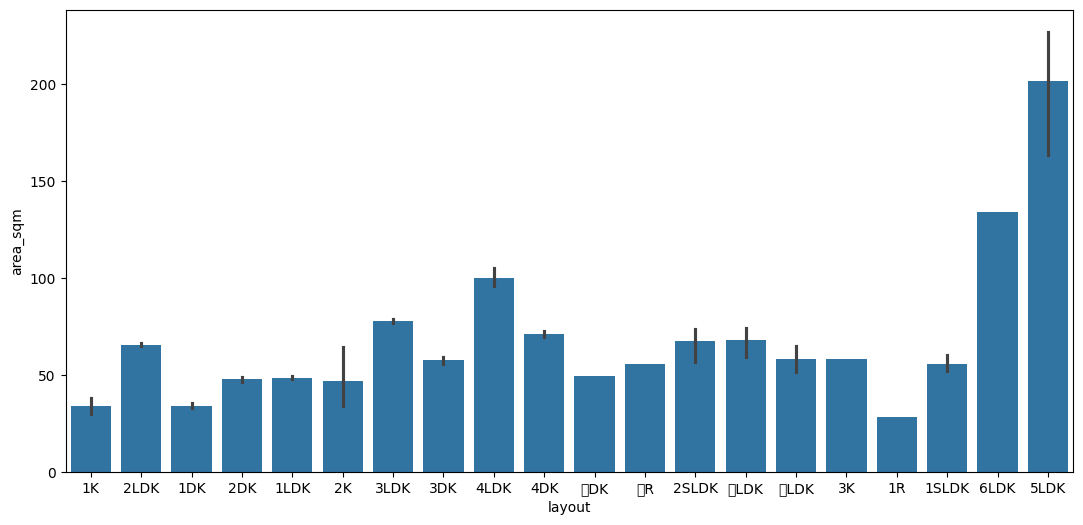

In [42]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=listing_data, x=listing_data['layout'], y=listing_data['area_sqm'], ax=ax)

## try to reformat the layout to be easier to use during preprocessing


In [51]:
import re
import numpy as np
import pandas as pd
from sklearn.preprocessing import FunctionTransformer

_layout_re = re.compile(r"^\s*(\d+)\s*(S?)\s*(LDK|DK|K|R)\s*$", re.IGNORECASE)

_fw_digits = str.maketrans("０１２３４５６７８９", "0123456789")

def parse_layout(X):
    """
    Input: X as 2D array (n_samples, 1) containing layout strings
    Output: DataFrame with columns:
      - rooms_num (int)
      - base_layout (str: LDK/DK/K/R)
      - has_S (int 0/1)
    """
    s = pd.Series(np.asarray(X).ravel()).fillna("").astype(str)
    s = s.str.translate(_fw_digits).str.strip().str.upper()

    rooms = []
    base = []
    has_s = []

    for val in s:
        m = _layout_re.match(val)
        if not m:
            rooms.append(np.nan)
            base.append("UNKNOWN")
            has_s.append(0)
        else:
            rooms.append(int(m.group(1)))
            has_s.append(1 if m.group(2) == "S" else 0)
            base.append(m.group(3))  # LDK/DK/K/R

    return pd.DataFrame({
        "rooms_num": rooms,
        "base_layout": base,
        "has_S": has_s
    })

layout_parser = FunctionTransformer(parse_layout, feature_names_out="one-to-one")

In [58]:
layout = listing_data['layout']
layout

3         1K
4       2LDK
5        1DK
6       2LDK
7        2DK
        ... 
5074    2LDK
5075    2LDK
5076    2LDK
5077    2LDK
5078    3LDK
Name: layout, Length: 3908, dtype: str

In [70]:
layout_parsed = parse_layout(layout)
layout_parsed['has_S'].value_counts()
layout_parsed = layout_parsed.drop(['has_S'], axis= 1)
listing_data = listing_data.reset_index().join(layout_parsed).drop(['layout'], axis=1)


In [ ]:
listing_data

,index,source_id,url,price_man_yen,area_sqm,year_built,floor_number,floors_total,address,nearest_station,walk_minutes,image_count,rooms_num,base_layout
0,3,20101205,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1480.0,32.72,1988,4.0,4.0,東京都足立区栗原２ [ ■ 周辺環境 ],西新井駅,10.0,10,1,K
1,4,20277732,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2390.0,52.89,1989,4.0,4.0,東京都足立区六月１ [ ■ 周辺環境 ],竹ノ塚駅,16.0,24,2,LDK
2,5,20332918,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1580.0,29.16,1976,6.0,9.0,東京都足立区東和５ [ ■ 周辺環境 ],北綾瀬駅,12.0,31,1,DK
3,6,20344616,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2380.0,53.04,1974,3.0,8.0,東京都足立区梅田７-22-9 [ ■ 周辺環境 ],梅島駅,7.0,27,2,LDK
4,7,78385243,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_7...,1700.0,40.10,1985,1.0,5.0,東京都足立区青井１-16-9 [ ■ 周辺環境 ],青井駅,10.0,11,2,DK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3903,5074,78586303,https://suumo.jp/ms/chuko/tokyo/sc_shinjuku/nc...,19990.0,79.02,2007,20.0,1.0,東京都新宿区四谷４ [ ■ 周辺環境 ],四谷三丁目駅,5.0,28,2,LDK
3904,5075,78530920,https://suumo.jp/ms/chuko/tokyo/sc_sumida/nc_7...,21800.0,80.38,2006,38.0,2.0,東京都墨田区太平４-１－１ [ ■ 周辺環境 ],錦糸町駅,4.0,29,2,LDK
3905,5076,20331756,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,29800.0,96.40,2005,1.0,1.0,東京都渋谷区広尾３ [ ■ 周辺環境 ],恵比寿駅,16.0,13,2,LDK
3906,5077,20352336,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,45800.0,91.39,2026,1.0,1.0,東京都渋谷区大山町 [ ■ 周辺環境 ],代々木上原駅,8.0,21,2,LDK


In [79]:
listing_data['nearest_station'].value_counts().tail(30)

nearest_station
上中里駅      1
仲御徒町駅     1
熊野前駅      1
練馬春日町駅    1
有楽町駅      1
鐘ヶ淵駅      1
豪徳寺駅      1
南新宿駅      1
立会川駅      1
雪が谷大塚駅    1
東長崎駅      1
保谷駅       1
荏原中延駅     1
志茂駅       1
西早稲田駅     1
洗足池駅      1
鶯谷駅駅      1
東松原駅      1
北品川駅      1
戸越公園駅     1
緑が丘駅      1
下高井戸駅     1
青物横丁駅     1
久が原駅      1
晴海埠頭駅     1
国際展示場駅    1
新橋駅       1
宝町駅       1
東北沢駅      1
国立競技場駅    1
Name: count, dtype: int64

## delete folders from suumo_images that are no longer needed


In [25]:
# ids_to_delete = listing_data[listing_data['image_count'] < 5]['source_id']
# len(ids_to_delete)

In [26]:
# def delete_folder_by_name(source_id):
#     """
#     Deletes a folder and all its contents recursively.

#     Args:
#         folder_path (str or path-like object): The path to the folder to be deleted.
#     """
#     source_id = 0000
#     folder_path = f'raw_data/suumo_images/{source_id}'
#     if os.path.isdir(folder_path):
#         try:
#             # Recursively remove the directory and all its contents
#             shutil.rmtree(folder_path)
#             print(f"Directory '{folder_path}' has been removed successfully.")
#         except OSError as e:
#             print(f"Error: {folder_path} : {e.strerror}")
#     else:
#         print(f"Error: Directory '{folder_path}' not found or is not a directory.")